In [1]:
import pandas as pd
import numpy as np
import os
import csv
import datetime as d
from datetime import datetime as D
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import random 
import time
import math
import scipy
from scipy import stats
from scipy.stats import norm

In [1]:
import sys
data_path = '../data/github/'
sys.path.append('../codes/')
from SEIVR import *
from data_input import *

In [2]:
data_path = '../data/github/'
target_phase2 = pd.read_csv(data_path+'target-data/target_data_phase2.csv')

In [3]:
# Convert 'date' column to datetime
target_phase2['date'] = pd.to_datetime(target_phase2['date'])
# Separate data based on the 'target' column
target_case = target_phase2[target_phase2['target'] == 'inc case']
target_death = target_phase2[target_phase2['target'] == 'inc death']
%run ../codes/data_input.py

In [4]:
suppressed_races = []
for r in race_list_06:
    s = np.sum(target_death[(target_death['race_ethnicity']==r)&(target_death['location']==6)]['min_suppressed'].values)
    suppressed_races.append(s)

In [5]:
target_death.loc[target_death['location']==37,'suppressed'] = target_death.loc[target_death['location']==37,'min_suppressed']*1
target_death.loc[target_death['location']==6,'suppressed'] = target_death.loc[target_death['location']==6,'min_suppressed']*1
target_death.loc[:,'adjusted'] = target_death.loc[:,'suppressed'].copy() + target_death.loc[:,'value'].copy()

/var/folders/_0/2l3z2qss74scb88wvbv1szxr0000gn/T/ipykernel_72571/2619552443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_death.loc[target_death['location']==37,'suppressed'] = target_death.loc[target_death['location']==37,'min_suppressed']*1
/var/folders/_0/2l3z2qss74scb88wvbv1szxr0000gn/T/ipykernel_72571/2619552443.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_death.loc[:,'adjusted'] = target_death.loc[:,'suppressed'].copy() + target_death.loc[:,'value'].copy()


In [59]:
target_death[(target_death['race_ethnicity']=='other')&(target_death['location']==6)]['adjusted'].values

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,
        2.,  3.,  3.,  2.,  2.,  3.,  2.,  3.,  2.,  3.,  0.,  3.,  2.,
        3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  2.,
        2.,  3.,  2.,  3.,  3.,  3.,  3.,  3.,  3.,  3., 29., 47., 64.,
       87., 76., 75., 65., 61., 35., 47.,  3.,  3.,  3.,  3.,  3.,  3.,
        2.])

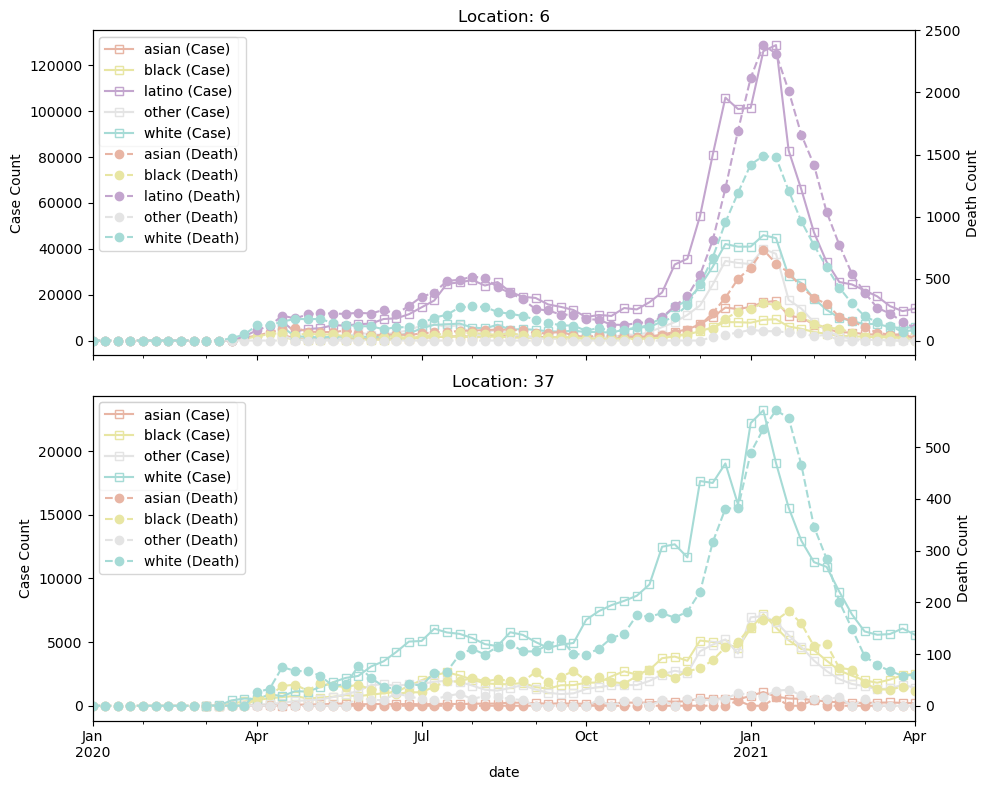

In [6]:
locations = sorted(set(target_case['location'].unique()).union(target_death['location'].unique()))
num_locations = len(locations)

fig, axes = plt.subplots(nrows=num_locations, ncols=1, figsize=(10, num_locations * 4), sharex=True)

for idx, location in enumerate(locations):
    ax = axes[idx]
    
    # Plot 'inc case' on primary y-axis with empty squares
    for race, group in target_case[target_case['location'] == location].groupby('race_ethnicity'):
        group.plot(x='date', y='value', ax=ax, label=f"{race} (Case)", marker='s', linestyle='-', color=custom_colors[race], fillstyle='none')

    # Create a secondary y-axis for 'inc death' 
    ax2 = ax.twinx()
    for race, group in target_death[target_death['location'] == location].groupby('race_ethnicity'):
        group.plot(x='date', y='value', ax=ax2, label=f"{race} (Death)", marker='o', linestyle='--', color=custom_colors[race])

    ax.set_title(f"Location: {location}")
    ax.set_ylabel('Case Count')
    ax2.set_ylabel('Death Count')
    
    # Combine legends from both axes
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.xlabel('Date')
plt.tight_layout()
plt.show()

In [48]:
grouped_case = target_case.groupby(['date','location'])['value'].sum().reset_index()
grouped_death = target_death.groupby(['date','location'])['value'].sum().reset_index()

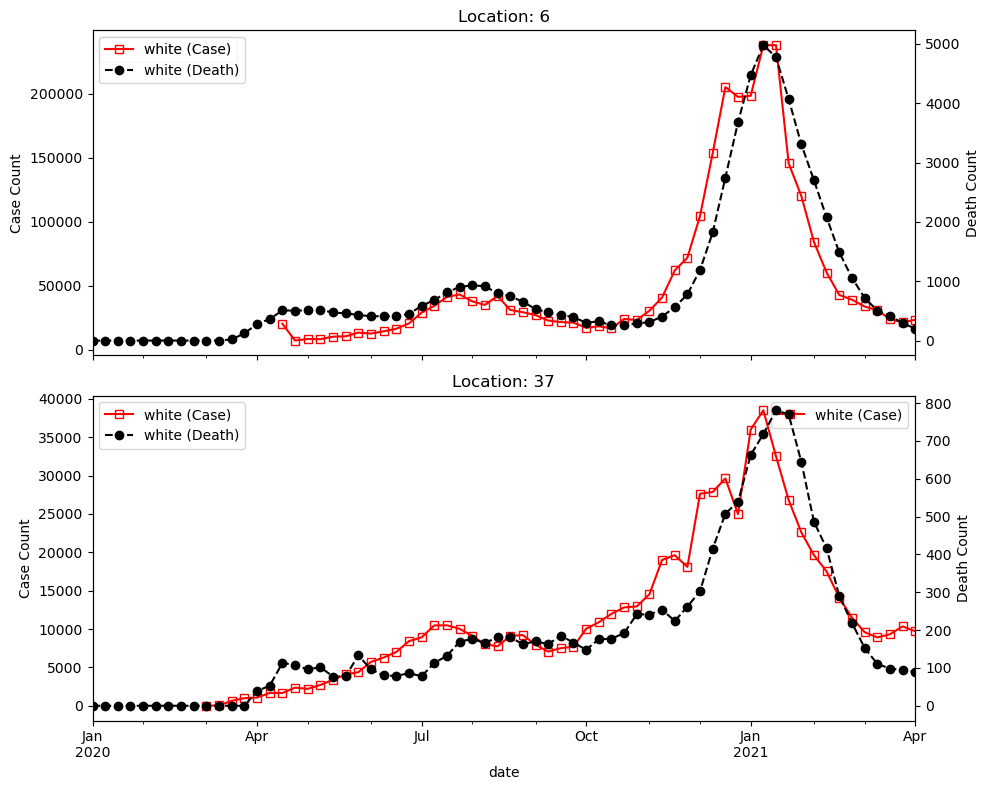

In [49]:
fig, axes = plt.subplots(nrows=num_locations, ncols=1, figsize=(10, num_locations * 4), sharex=True)

for idx, location in enumerate(locations):
    ax = axes[idx]
    
    # Plot 'inc case' on primary y-axis with empty squares
    cases = grouped_case[grouped_case['location'] == location]
    cases.plot(x='date', y='value', ax=ax, label=f"{race} (Case)", marker='s', linestyle='-', color='red', fillstyle='none')

    # Create a secondary y-axis for 'inc death' 
    ax2 = ax.twinx()
    deaths = grouped_death[grouped_death['location'] == location]
    deaths.plot(x='date', y='value', ax=ax2, label=f"{race} (Death)", marker='o', linestyle='--', color='black')

    ax.set_title(f"Location: {location}")
    ax.set_ylabel('Case Count')
    ax2.set_ylabel('Death Count')
    
    # Combine legends from both axes
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.xlabel('Date')
plt.tight_layout()
plt.show()

In [7]:
locations = sorted(set(target_case['location'].unique()).union(target_death['location'].unique()))
num_locations = len(locations)

In [8]:
populations = pd.read_csv(data_path+'population_data/population_data.csv')
populations_06 = populations[populations['location'] == 6]
populations_37 = populations[populations['location'] == 37]

In [52]:
target_case.head()
cases_06 = {}
cases_06_list = []
for r in race_list_06:
    print(r)
    df_r = target_case[(target_case['location'] == 6)&(target_case['race_ethnicity'] == r)]
    df_r_sorted = df_r.sort_values(by='date')
    # print ('starting', df_r_sorted['date'].values[0])
    cases_06[r] = df_r_sorted['value'].values
    cases_06_list.append(list(df_r_sorted['value']))

asian
white
black
latino
other


In [9]:
target_case.head()
cases_37 = {}
cases_37_list = []
### There is no latino in loction 37
for r in race_list_37:
    print(r)
    df_r = target_case[(target_case['location'] == 37)&(target_case['race_ethnicity'] == r)]
    df_r_sorted = df_r.sort_values(by='date')
    # print ('starting', df_r_sorted['date'].values[0])
    cases_37[r] = df_r_sorted['value'].values
    cases_37_list.append(list(df_r_sorted['value']))

asian
white
black
other


In [17]:
cases_06_array = np.array(cases_06_list).T
# np.savetxt('cases_06.csv', cases_06_array, delimiter=',')
cases_37_array = np.array(cases_37_list).T
# np.savetxt('cases_37.csv', cases_37_array, delimiter=',')

In [18]:
cases_06_array.shape

(51, 5)

In [60]:
deaths_06 = {}
deaths_06_list = []
for r in race_list_06:
    print(r)
    df_r = target_death[(target_death['location'] == 6)&(target_death['race_ethnicity'] == r)]
    df_r_sorted = df_r.sort_values(by='date')
    # print ('starting', df_r_sorted['date'].values[0])
    # deaths_06[r] = df_r_sorted['value'].values
    deaths_06[r] = df_r_sorted['adjusted'].values
    # deaths_06_list.append(list(df_r_sorted['value']))
    deaths_06_list.append(list(df_r_sorted['adjusted']))

asian
white
black
latino
other


In [10]:
deaths_37 = {}
deaths_37_list = []
for r in race_list_37:
    print(r)
    df_r = target_death[(target_death['location'] == 37)&(target_death['race_ethnicity'] == r)]
    df_r_sorted = df_r.sort_values(by='date')
    # print ('starting', df_r_sorted['date'].values[0])
    # deaths_37[r] = df_r_sorted['value'].values
    deaths_37[r] = df_r_sorted['adjusted'].values
    # deaths_37_list.append(list(df_r_sorted['value']))
    deaths_37_list.append(list(df_r_sorted['adjusted']))

asian
white
black
other


In [11]:
# deaths_06_array = np.array(deaths_06_list).T
# np.savetxt('deaths_06_phase2_v3.csv', deaths_06_array, delimiter=',')
deaths_37_array = np.array(deaths_37_list).T
np.savetxt('deaths_37_phase2_v3.csv', deaths_37_array, delimiter=',')